Scan free parameters in the Saarelma et al., 2023 model. These parameters are:
    alpha_crit : float
        FREE PARAMETER, Critical alpha value for onset of infinite-n ballooning instability, dimensionless
    C_KBM : float
        FREE PARAMETER, KBM diffusion coefficient, m^2/s
    De_chie_etg : float
        FREE PARAMETER, ETG diffusion coefficient, m^2/s
    nFC_x0 : float
        m^-3, FREE PARAMETER, Franck-Condon neutral density at the separatrix (boundary condition)

In [1]:
import sys
import gc
from pathlib import Path
import csv
import os


# Put repo root on path so `src` is importable (parent of this notebook's folder).
ROOT = Path.cwd()
ROOT = ROOT.parent.parent
sys.path.insert(0, str(ROOT))

from src.solver import saarelma_connor
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Input files
mhd_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/g152960.03500' # filepath to MHD paramter file
kprof_fp = '/Users/nelsonlab/codes/saarelma-conner-ped/src/inputs/PT_Hmode/p152960.03500' # filepath to kinetic paramter file

# Scan size
N = 5

# Scan parameters
# alpha_crits = np.linspace(0.01, 2.0, 3)
# C_KBMs = np.linspace(0.01, 0.9, 3)
# De_chie_etgs = np.linspace(0.01, 0.9, 3)
# nFC_x0s = np.linspace(5e14, 9e15, 3)
alpha_crits = np.logspace(-2, 1.5, N)
C_KBMs = np.logspace(-1, 1.5, N)
De_chie_etgs = np.logspace(-1, 1.5, N)
nFC_x0s = np.logspace(15.5, 18.5, N)
# Inner-boundary threshold (used to compute the OUTER limit of the
# psi_N_inner_boundary scan range; smaller -> outer limit further inward).
boundary_threshold = 1e-6
# Number of points to sample between (slope-zero inner limit) and (outer limit).
n_psi_inner_pts = N
# Safety margin for the inner limit: place the deepest valid boundary at
# psi_N where dne/dx = safety_margin * min(dne/dx) rather than exactly 0.
psi_inner_safety_margin = 0.01

# Static parameters
P_tot_e = 5e6 # W, total heating power given to electrons (can be assumed to be half the total heating power according to S. Saarelma et al 2023 Nucl. Fusion 63 052002), will be read from TokTox
solve_res = 100

# Output data and files
success_fp = 'success_PTHmode.txt'
failure_fp = 'failure_PTHmode.txt'
error_messages_fp = 'error_messages_PTHmode.txt'
with open(success_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(failure_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner\n")
with open(error_messages_fp, 'w') as f:
        f.write(f"alpha_crit, C_KBM, De_chie_etg, nFC_x0, psi_N_inner, message\n")
ne_success_fp = 'scan_success_PTHmode'
verbose = False

In [9]:
# Build the model once — the expensive flux-surface-averaging and equilibrium
# loading runs here only, not inside the loop.
base_model = saarelma_connor(
        P_tot_e     = P_tot_e,
        alpha_crit  = round(float(alpha_crits[0]), 3),
        C_KBM       = round(float(C_KBMs[0]), 3),
        De_chie_etg = round(float(De_chie_etgs[0]), 3),
        nFC_x0      = round(float(nFC_x0s[0]), 3),
        mhd_fp      = mhd_fp,
        kprof_fp    = kprof_fp,
        verbose     = verbose,
        nFC_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
        nCX_threshold = boundary_threshold, # used initially to compute the outer limit of the boundary range
)
print("Base model built — starting scan.")

# Lightweight RAM reporter (no external deps)
import resource
def _ram_mb():
    rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    # macOS returns bytes; Linux returns kB
    return rss / (1024 ** 2) if sys.platform == 'darwin' else rss / 1024

# Delete all files in ne_success_fp
for file in os.listdir(ne_success_fp):
    os.remove(os.path.join(ne_success_fp, file))

# run scan: for each (alpha_crit, C_KBM, De_chie_etg, nFC_x0) we recompute
# the valid range of psi_N_inner_boundary from the slope-zero inner limit to
# the nFC/nCX-threshold outer limit, then sample n_psi_inner_pts boundaries.
n_iter = 0
i=0
for alpha_crit in alpha_crits:
        j=0
        for C_KBM in C_KBMs:
                k=0
                for De_chie_etg in De_chie_etgs:
                        l=0
                        for nFC_x0 in nFC_x0s:
                                ac = round(float(alpha_crit), 3)
                                ck = round(float(C_KBM), 3)
                                de = round(float(De_chie_etg), 3)
                                nf = round(float(nFC_x0), 3)

                                # Step 1: apply free params with adaptive thresholds active so
                                # inner_boundary_limits can compute the outer limit correctly.
                                base_model.update_free_params(
                                        alpha_crit    = ac,
                                        C_KBM         = ck,
                                        De_chie_etg   = de,
                                        nFC_x0        = nf,
                                        nFC_threshold = boundary_threshold,
                                        nCX_threshold = boundary_threshold,
                                )
                                try:
                                        psi_inner_lim, psi_outer_lim = base_model.inner_boundary_limits(
                                                outer_threshold = boundary_threshold,
                                                x_res           = solve_res,
                                        )
                                except Exception as e:
                                        # Range computation failed; log and skip this combination.
                                        with open(error_messages_fp, 'a') as f:
                                                f.write(f"{ac}, {ck}, {de}, {nf}, range_failed, {e}\n")
                                        continue

                                if psi_inner_lim >= psi_outer_lim:
                                        psi_scan = np.array([psi_outer_lim])
                                else:
                                        psi_scan = np.linspace(psi_inner_lim, psi_outer_lim, n_psi_inner_pts)

                                m=0
                                for psi_b in psi_scan:
                                        psi_val = round(float(psi_b), 4)
                                        try:
                                                base_model.update_free_params(
                                                        alpha_crit            = ac,
                                                        C_KBM                 = ck,
                                                        De_chie_etg           = de,
                                                        nFC_x0                = nf,
                                                        psi_N_inner_boundary  = psi_val,
                                                )
                                                base_model.solve(x_res=solve_res)
                                        except Exception as e: # run fails
                                                with open(failure_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                with open(error_messages_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}, {e}\n")
                                                m+=1
                                        else: # run works
                                                with open(success_fp, 'a') as f:
                                                        f.write(f"{ac}, {ck}, {de}, {nf}, {psi_val:.4f}\n")
                                                np.save(f'{ne_success_fp}/ne_a{ac}_C{ck}_D{de}_n{nf}_b{psi_val:.4f}', base_model.sol, allow_pickle=True)
                                                m+=1
                                        n_iter += 1
                                        if n_iter % 10 == 0:
                                                gc.collect()
                                                print(f"  [{n_iter} iters] peak RAM ~ {_ram_mb():.0f} MB")
                                l+=1
                                print(f"Completed {l} of {len(nFC_x0s)} nFC_x0s  [psi_N range: {psi_inner_lim:.3f}..{psi_outer_lim:.3f}]") # progress logging
                        k+=1
                        print(f"Completed {k} of {len(De_chie_etgs)} De_chie_etgs") # progress logging
                j+=1
                print(f"Completed {j} of {len(C_KBMs)} C_KBMs") # progress logging
        i+=1
        print(f"Completed {i} of {len(alpha_crits)} alpha_crits") # progress logging

Base model built — starting scan.
psi_N_inner_boundary: 0.9141
x_inner: -0.0354 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
Completed 1 of 5 nFC_x0s  [psi_N range: 0.850..0.914]
psi_N_inner_boundary: 0.9141
x_inner: -0.0354 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
  [10 iters] peak RAM ~ 310 MB
Completed 2 of 5 nFC_x0s  [psi_N range: 0.850..0.914]
psi_N_inner_boundary: 0.9141
x_inner: -0.0354 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
Completed 3 of 5 nFC_x0s  [psi_N range: 0.850..0.914]
psi_N_inner_boundary: 0.9141
x_inner: -0.0354 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
  [20 iters] peak RAM ~ 310 MB
Completed 4 of 5 nFC_x0s  [psi_N range: 0.850..0.914]
psi_N_inner_boundary: 0.9141
x_inner: -0.0354 m
No valid inner boundary found, defaulting to psi_N=0.85 for inner boundary
Completed 5 of 5 nFC_x0s  [psi_N range: 0.850..0.914]
Completed 1 of 5 De

PLOTTING AND ANALYSIS

In [ ]:
# success/failure heat maps of each slice of two of the variables of choice

# variables to slice on
slice_var1_name = 'alpha_crit'
slice_var2_name = 'De_chie_etg'

# value of variables to slice on
slice_var1 = 0.01
slice_var2 = 0.9

# ne_success = []
names = ['alpha_crit', 'C_KBM', 'De_chie_etg', 'nFC_x0']

idx_var = [names.index(slice_var1_name), names.index(slice_var2_name)]
idx_notvar = [i for i in range(len(names)) if i not in idx_var]

var1 = []
var2 = []
with open(success_fp, newline="") as f:
    reader = csv.reader(f)
    header = next(reader)  # skip: alpha_crit, C_KBM, ...
    for row in reader:
        numbers = [float(x.strip()) for x in row]
        # alpha_crit, C_KBM, De_chie_etg, nFC_x0 = numbers
        if numbers[idx_var[0]] == slice_var1 or numbers[idx_var[1]] == slice_var1: # sliced row
            if numbers[idx_var[0]] == slice_var2 or numbers[idx_var[1]] == slice_var2: # sliced row
                var1.append(numbers[idx_notvar[0]])
                var2.append(numbers[idx_notvar[1]])



In [ ]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Map each parameter name to its scan array
scan_arrays = {
    'alpha_crit':  alpha_crits,
    'C_KBM':       C_KBMs,
    'De_chie_etg': De_chie_etgs,
    'nFC_x0':      nFC_x0s,
}

# Derive axis labels and tick values automatically from idx_notvar and names
x_name = names[idx_notvar[0]]
y_name = names[idx_notvar[1]]
x_vals = sorted(set(round(v, 3) for v in scan_arrays[x_name]))
y_vals = sorted(set(round(v, 3) for v in scan_arrays[y_name]))

title = (f"Success / Failure  "
         f"({slice_var1_name}={slice_var1}, {slice_var2_name}={slice_var2})")

# Set of successful (x, y) pairs collected above
success_pairs = set(zip(var1, var2))

# Build binary grid: 1 = success (green), 0 = failure (red)
grid = np.zeros((len(y_vals), len(x_vals)))
for xi, x in enumerate(x_vals):
    for yi, y in enumerate(y_vals):
        if (x, y) in success_pairs:
            grid[yi, xi] = 1

fig, ax = plt.subplots(figsize=(8, 6))
cmap = ListedColormap(["red", "green"])
ax.imshow(grid, cmap=cmap, vmin=0, vmax=1, aspect="auto", origin="lower")

# dot at every grid point
for xi in range(len(x_vals)):
    for yi in range(len(y_vals)):
        ax.plot(xi, yi, "k.", markersize=8)

ax.set_xticks(range(len(x_vals)))
ax.set_xticklabels([f"{v:.3g}" for v in x_vals], rotation=45, ha="right")
ax.set_yticks(range(len(y_vals)))
ax.set_yticklabels([f"{v:.3g}" for v in y_vals])
ax.set_xlabel(x_name)
ax.set_ylabel(y_name)
ax.set_title(title)

ax.legend(
    handles=[Patch(facecolor="green", label="Success"),
             Patch(facecolor="red",   label="Failure")],
    loc="upper right",
)

plt.tight_layout()
plt.show()

Experimental p-file peak n_e: 6.841e+19 m^-3
rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0   psi_inner     peak_model (m^-3)    |delta peak|
-------------------------------------------------------------------------------------------------------
   1       0.562       7.5          0.1      3.16e+18      0.9141             2.517e+19       4.324e+19
   2       0.562      1.78          0.1      5.62e+17      0.9141             2.159e+19       4.683e+19
   3       0.562     0.422          0.1         1e+17      0.9141             1.772e+19       5.069e+19
   4       0.075       7.5          7.5      3.16e+18      0.9141             1.679e+19       5.162e+19
   5        0.01       7.5          7.5      3.16e+18      0.9141             1.679e+19       5.163e+19
   6       0.562      31.6          0.1      3.16e+18      0.9141             1.664e+19       5.177e+19
   7       0.562      31.6        0.422      3.16e+18      0.9141             1.652e+19       5.189e+19
   8       0.562   

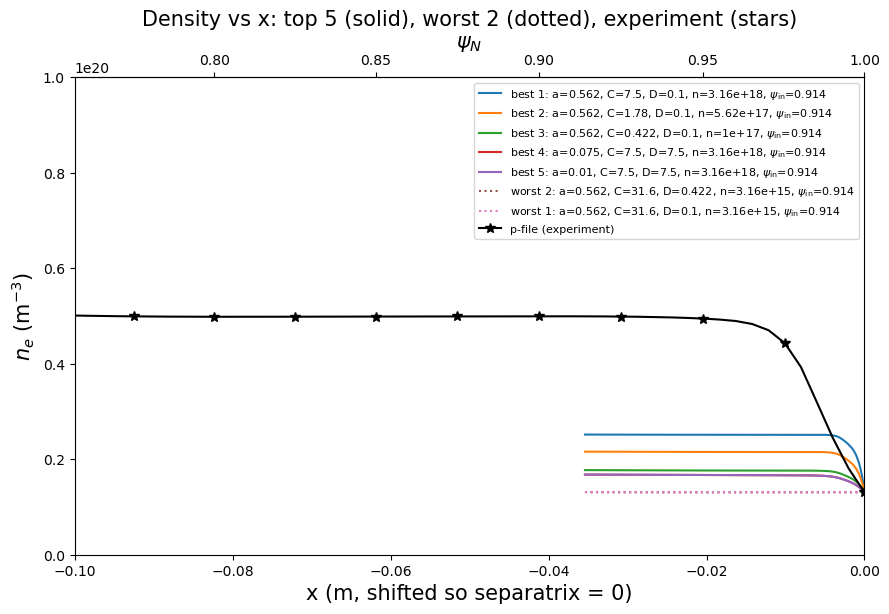

In [10]:
# Determine which combination of parameters in all the successful runs best matches the initial p file's density peak
# Output ordered list of which parameter combinations best match to which worst match, including how far from the density peak they are

import re
from pathlib import Path
from scipy.interpolate import interp1d

# 1. Peak density from the experimental p-file (m^-3)
def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if '3 N Z A' in line:
                break
            if line.startswith('201'):
                in_ne_block = 'ne(10^20/m^3)' in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20  # m^-3

psi_pfile, ne_pfile = read_pfile_ne(kprof_fp)
peak_pfile = ne_pfile.max()
print(f"Experimental p-file peak n_e: {peak_pfile:.3e} m^-3")

# Build psi_N -> x mapping once (reused in cell 8)
ref = saarelma_connor(
    P_tot_e=P_tot_e,
    alpha_crit=alpha_crits[0],
    C_KBM=C_KBMs[0],
    De_chie_etg=De_chie_etgs[0],
    nFC_x0=nFC_x0s[0],
    mhd_fp=mhd_fp,
    kprof_fp=kprof_fp,
    verbose=False,
)
psi_to_x = interp1d(ref.psi_N_pres, ref.r_psi - ref.r_psi[-1],
                    kind='linear', bounds_error=False, fill_value='extrapolate')
# Inverse map for the secondary axis (x in meters -> psi_N).
x_to_psi = interp1d(ref.r_psi - ref.r_psi[-1], ref.psi_N_pres,
                    kind='linear', bounds_error=False, fill_value='extrapolate')

# Experimental ne mapped to x
x_pfile = psi_to_x(psi_pfile)

# 2. For each successful run, load the saved sol and compute its peak n_e
scan_dir = Path(ne_success_fp)
pattern = re.compile(r"_([a-zA-Z])([\d.eE+-]+)")

results = []
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    peak_model = sol.y[0].max() # realistic profile should peak at psi_N = 0.85 so this should be okay
    distance = abs(peak_model - peak_pfile)
    results.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'psi_inner':   params.get('b'),  # explicit psi_N_inner_boundary
        'peak_model':  peak_model,
        'distance':    distance,
        'sol_x':       sol.x,
        'sol_ne':      sol.y[0],
    })

# 3. Sort best -> worst by absolute peak difference
results.sort(key=lambda r: r['distance'])

# 4. Print ordered table
header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'psi_inner':>10}  {'peak_model (m^-3)':>20}  {'|delta peak|':>14}")
print(header)
print("-" * len(header))
for rank, r in enumerate(results, start=1):
    psi_str = f"{r['psi_inner']:.4f}" if r['psi_inner'] is not None else "n/a"
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  {psi_str:>10}  "
          f"{r['peak_model']:>20.3e}  {r['distance']:>14.3e}")

# 5. Plot top 5 best (solid), worst 2 (dotted), p-file (line + stars)
def _label(r):
    psi_str = f"{r['psi_inner']:.3f}" if r['psi_inner'] is not None else "n/a"
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            r"$\psi_{\mathrm{in}}$=" + psi_str)

fig, ax = plt.subplots(figsize=(9, 6))
i = 0
for r in results[:5]:
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f"best {i+1}: {_label(r)}")
    i += 1
i=0
for r in results[-2:]:
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f"worst {2-i}: {_label(r)}")
    i += 1
ax.plot(x_pfile, ne_pfile, '-*', color='black', markevery=5,
        markersize=7, label='p-file (experiment)')
ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.set_title('Density vs x: top 5 (solid), worst 2 (dotted), experiment (stars)', fontsize=15)
ax.legend(fontsize=8, loc='best')
# plt.xlim([r['sol_x'][0], r['sol_x'][-1]])
ax.set_xlim(-0.1, 0)
ax.set_ylim(0, 1e20)
# Secondary x-axis on top showing psi_N (uses the bidirectional x<->psi_N map)
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
plt.tight_layout()
plt.show()


rank  alpha_crit     C_KBM  De_chie_etg        nFC_x0   psi_inner       L2 (m^-3)
---------------------------------------------------------------------------------
   1       0.562       7.5          0.1      3.16e+18      0.9141       2.252e+19
   2       0.562      1.78          0.1      5.62e+17      0.9141       2.590e+19
   3       0.562     0.422          0.1         1e+17      0.9141       2.959e+19
   4       0.075       7.5          7.5      3.16e+18      0.9141       3.050e+19
   5        0.01       7.5          7.5      3.16e+18      0.9141       3.050e+19
   6       0.562      31.6          0.1      3.16e+18      0.9141       3.061e+19
   7       0.562      31.6        0.422      3.16e+18      0.9141       3.073e+19
   8       0.562      31.6         1.78      3.16e+18      0.9141       3.109e+19
   9       0.075      31.6         1.78      3.16e+18      0.9141       3.126e+19
  10        0.01      31.6         1.78      3.16e+18      0.9141       3.128e+19
  11       0.075

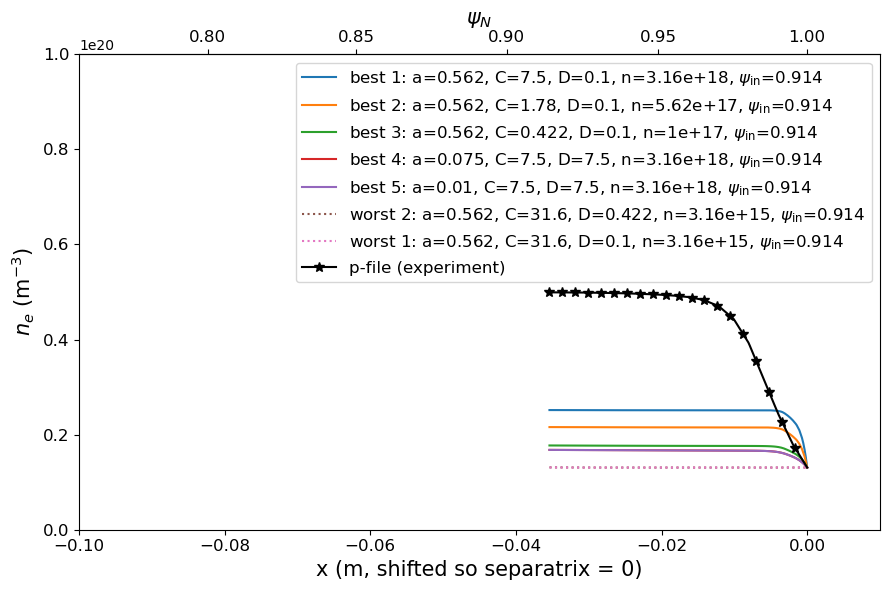

In [11]:
# Determine which combination of parameters in all the successful runs best matches the initial p file's pedestal density (L2 distance of each point)

# Pedestal grid (psi_N = 0.85 .. 1.0); psi_to_x was built in cell 7.
# L2 is still scored on this common grid so the ranking is comparable across
# runs that solved on different x domains.
psi_ped = np.linspace(0.85, 1.0, 200)
x_ped = psi_to_x(psi_ped)  # m, shifted so separatrix = 0

# Experimental ne on the pedestal grid (m^-3)
ne_pfile_ped = interp1d(psi_pfile, ne_pfile, kind='linear',
                        bounds_error=False, fill_value='extrapolate')(psi_ped)
# Experimental ne on each run's own x domain is computed inside the loop
ne_pfile_of_x = interp1d(x_pfile, ne_pfile, kind='linear',
                         bounds_error=False, fill_value='extrapolate')

# Compare each successful run's predicted profile to the experimental profile
results_l2 = []
for npy_path in scan_dir.glob("ne_*.npy"):
    pairs = pattern.findall(npy_path.stem)
    params = {letter: float(num) for letter, num in pairs}
    sol = np.load(npy_path, allow_pickle=True).item()
    ne_pred_ped = interp1d(sol.x, sol.y[0], kind='linear',
                           bounds_error=False, fill_value='extrapolate')(x_ped)
    l2 = np.sqrt(np.mean((ne_pred_ped - ne_pfile_ped) ** 2))  # RMS in m^-3
    results_l2.append({
        'alpha_crit':  params.get('a'),
        'C_KBM':       params.get('C'),
        'De_chie_etg': params.get('D'),
        'nFC_x0':      params.get('n'),
        'psi_inner':   params.get('b'),  # explicit psi_N_inner_boundary
        'l2':          l2,
        'sol_x':       sol.x,        # solver's own domain
        'sol_ne':      sol.y[0],     # solver's own profile
    })

results_l2.sort(key=lambda r: r['l2'])

header = (f"{'rank':>4}  {'alpha_crit':>10}  {'C_KBM':>8}  {'De_chie_etg':>11}  "
          f"{'nFC_x0':>12}  {'psi_inner':>10}  {'L2 (m^-3)':>14}")
print(header)
print("-" * len(header))
for rank, r in enumerate(results_l2, start=1):
    psi_str = f"{r['psi_inner']:.4f}" if r['psi_inner'] is not None else "n/a"
    print(f"{rank:>4}  {r['alpha_crit']:>10.3g}  {r['C_KBM']:>8.3g}  "
          f"{r['De_chie_etg']:>11.3g}  {r['nFC_x0']:>12.3g}  {psi_str:>10}  {r['l2']:>14.3e}")

# Plot top 5 best (solid), worst 2 (dotted) — each on its own solver domain.
# p-file (line + stars) is plotted on the union of all model domains.
def _label(r):
    psi_str = f"{r['psi_inner']:.3f}" if r['psi_inner'] is not None else "n/a"
    return (f"a={r['alpha_crit']:.3g}, C={r['C_KBM']:.3g}, "
            f"D={r['De_chie_etg']:.3g}, n={r['nFC_x0']:.3g}, "
            r"$\psi_{\mathrm{in}}$=" + psi_str)

fig, ax = plt.subplots(figsize=(9, 6))
for i, r in enumerate(results_l2[:5]):
    ax.plot(r['sol_x'], r['sol_ne'], '-', label=f"best {i+1}: {_label(r)}")
for i, r in enumerate(results_l2[-2:]):
    ax.plot(r['sol_x'], r['sol_ne'], ':', label=f"worst {2-i}: {_label(r)}")

# Use the widest model domain among the plotted runs as the experimental x range
plotted = results_l2[:5] + results_l2[-2:]
x_lo = min(r['sol_x'].min() for r in plotted)
x_hi = max(r['sol_x'].max() for r in plotted)
x_exp = np.linspace(x_lo, x_hi, 400)
ax.plot(x_exp, ne_pfile_of_x(x_exp), '-*', color='black', markevery=20,
        markersize=7, label='p-file (experiment)')

ax.set_xlabel('x (m, shifted so separatrix = 0)', fontsize=15)
ax.set_ylabel(r'$n_e$ (m$^{-3}$)', fontsize=15)
ax.legend(fontsize=12, loc='best')
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(-0.1, 0.01)
ax.set_ylim(0,1e20)
# Secondary x-axis on top showing psi_N (uses the bidirectional x<->psi_N map
# built in cell 7).
secax = ax.secondary_xaxis('top', functions=(x_to_psi, psi_to_x))
secax.set_xlabel(r'$\psi_N$', fontsize=15)
secax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
plt.show()